# Regresión Espacial SAR — Altitud media de los 491 altiplanos (v2)

## Introducción

**Qué se busca:** en `04_autocorrelacion_espacial_v2.ipynb` (Parte A) se encontró que
`Altitud_X` tiene el Moran's I más alto de las tres variables morfométricas (**I=0.920**,
p=0.001): los altiplanos con altitud similar están fuertemente agrupados en el espacio. Aquí
se retoma esa variable como respuesta de un modelo de regresión y se pregunta: ¿esa
autocorrelación espacial persiste incluso después de controlar por Pendiente y Relieve
(`Pend_X`, `Relieve_X`)? Si persiste, un modelo OLS clásico viola su supuesto de
independencia de los residuos, y hace falta un modelo espacial explícito (SLX/SEM/SAR-Lag).

**Método del libro utilizado:** `09_SpatialRegression` (diagnóstico OLS + SLX) y `10_SAR`
(SEM y SAR-Lag) del libro *Análisis Geoespacial* (Aristizábal). Se reutiliza la matriz de
pesos **KNN (k=6)**, la misma que usa `04_autocorrelacion_espacial_v2.ipynb` para el Moran's
I de estas variables, así los resultados son directamente comparables.

**Por qué KNN y no Queen/Rook:** igual que en `01_v2`/`02_v2`, los 491 polígonos de
altiplano no son contiguos entre sí, así que la contigüidad no aplica; KNN sobre los
centroides es el sustituto de vecindad usado en todo el proyecto para esta capa.

## Objetivos de aprendizaje
- Diagnosticar autocorrelación espacial en los residuos de un OLS con el Índice de Moran y
  las pruebas del Multiplicador de Lagrange (LM-error, LM-lag).
- Ajustar y comparar SLX, SEM (`GM_Error_Het`) y SAR-Lag (`GM_Lag`) con `spreg`.
- Interpretar el parámetro de dependencia espacial (λ en SEM, ρ en SAR-Lag) con su
  significancia.
- Comparar explícitamente cada modelo espacial contra el OLS no espacial equivalente.


## [0] Configuración: rutas, semilla y carpeta de resultados


In [1]:
import os
import struct   # leer el encabezado binario del .dbf (nombres de columna con acentos)
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
# --- Análisis espacial ---
from libpysal.weights import KNN                     # matriz de pesos por k-vecinos más cercanos
from libpysal.weights.spatial_lag import lag_spatial # rezago espacial (promedio de los vecinos)
import spreg                                          # modelos de regresión espacial (OLS, SLX, SEM, SAR-Lag)
import esda                                           # estadísticos de autocorrelación (Moran's I)

warnings.filterwarnings("ignore")

RUTA_SHP = r"C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Capas\Estadisticas_Cluster.shp"
RUTA_DBF = r"C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Capas\Estadisticas_Cluster.dbf"
CARPETA_RESULTADOS = r"C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados"
CARPETA_FIGURAS = os.path.join(CARPETA_RESULTADOS, "10_SAR_altiplanos_v2")
os.makedirs(CARPETA_FIGURAS, exist_ok=True)

SEMILLA = 42
np.random.seed(SEMILLA)   # esda.Moran no acepta 'seed'; se fija la semilla global de numpy

print(f"Carpeta de figuras de este notebook: {CARPETA_FIGURAS}")

Carpeta de figuras de este notebook: C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\10_SAR_altiplanos_v2


## [1] Utilidad: corrección de codificación del `.dbf` (idéntica a `01_v2`/`02_v2`)


In [2]:
def nombres_reales_columnas_dbf(ruta_dbf: str, encoding: str = "utf-8") -> list[str]:
    # Igual que en 01/03: lee los nombres de campo del encabezado binario del .dbf (respeta acentos).
    with open(ruta_dbf, "rb") as f:
        encabezado = f.read(32)                              # 32 bytes de cabecera
        tam_encabezado = struct.unpack("<H", encabezado[8:10])[0]   # tamaño del encabezado (2 bytes, little-endian)
        f.seek(0)
        encabezado_completo = f.read(tam_encabezado)
    nombres = []
    offset = 32
    while True:
        descriptor = encabezado_completo[offset:offset + 32]   # cada campo ocupa 32 bytes
        if descriptor[0:1] == b"\x0d" or len(descriptor) < 32:  # 0x0D = fin de la lista de campos
            break
        crudo = descriptor[0:11].split(b"\x00")[0]              # nombre = 11 bytes hasta el byte nulo
        nombres.append(crudo.decode(encoding))
        offset += 32
    return nombres

## [2] Carga de datos


In [3]:
gdf = gpd.read_file(RUTA_SHP)                                     # 491 polígonos de altiplano
gdf.columns = nombres_reales_columnas_dbf(RUTA_DBF) + ["geometry"]  # corrige nombres de columna (+ geometría)
print(f"Poligonos cargados: {len(gdf)}")

Poligonos cargados: 491


## [3] Exploración de datos

Estadísticas descriptivas e histogramas de la variable respuesta (`Altitud_X`) y los dos
predictores (`Pend_X`, `Relieve_X`). N=491 polígonos, sin exclusiones (datos vectoriales, ya
explorados a fondo en `01_clustering_altiplanos_v2.ipynb`; aquí se repite un resumen mínimo
por completitud, siguiendo la skill del proyecto).


In [4]:
variables_modelo = ["Altitud_X", "Pend_X", "Relieve_X"]   # Y = Altitud; X = Pendiente, Relieve
print(f"N = {len(gdf)} poligonos, sin exclusiones.")
gdf[variables_modelo].describe().T                        # estadísticas descriptivas (tabla)

N = 491 poligonos, sin exclusiones.


,count,mean,std,min,25%,50%,75%,max
Altitud_X,491.0,1258.583772,725.172427,412.92700,671.57250,1017.7000,1625.00000,3608.2600
Pend_X,491.0,11.977463,1.956846,6.80707,10.52895,12.1265,13.30865,18.2158
Relieve_X,491.0,44.420052,6.890411,26.68940,39.14650,44.7290,48.95435,76.2206


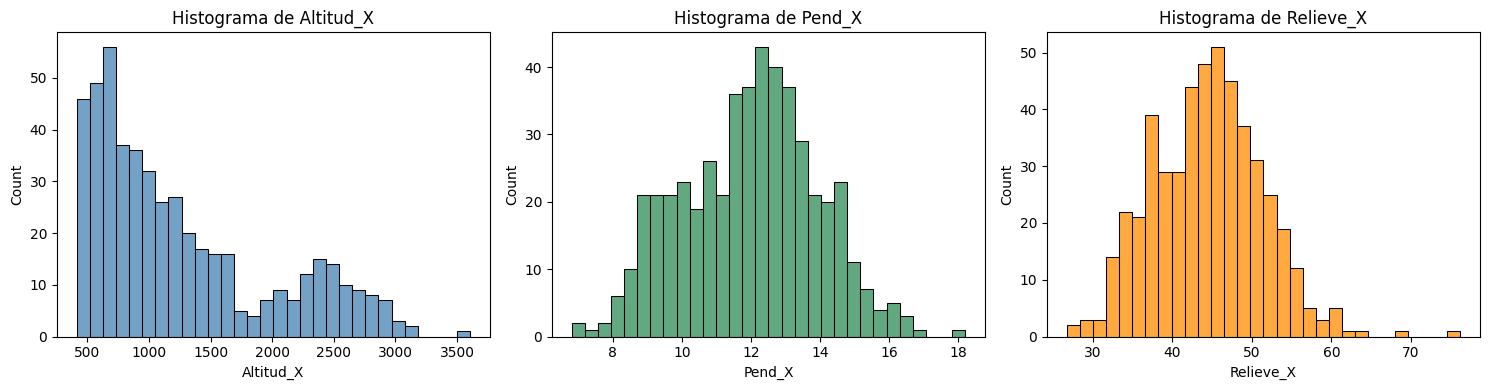

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))   # un histograma por variable del modelo
for ax, var, color in zip(axes, variables_modelo, ["steelblue", "seagreen", "darkorange"]):
    sns.histplot(gdf[var], bins=30, color=color, ax=ax)
    ax.set_title(f"Histograma de {var}")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, "00_histogramas_variables.png"), dpi=150)
plt.show()

## [4] Variable respuesta y predictores

**Y = `Altitud_X`** (altitud media del altiplano, estandarizada) — la variable con mayor
Moran's I global ya documentado (I=0.920 en `04_v2`).
**X = `Pend_X`, `Relieve_X`** (pendiente y relieve medios, estandarizados) — se excluyen las
demás variables morfométricas (percentiles de altitud, desviaciones estándar) para mantener
el modelo simple e interpretable; `Área` y `Geología` quedan fuera por las mismas razones ya
documentadas en `01_v2`.


In [6]:
# Estandariza X e Y por separado (media 0, desv. 1) para que los coeficientes sean comparables.
escalador_x = StandardScaler()
escalador_y = StandardScaler()
X = escalador_x.fit_transform(gdf[["Pend_X", "Relieve_X"]])   # predictores estandarizados (matriz Nx2)
y = escalador_y.fit_transform(gdf[["Altitud_X"]])             # respuesta estandarizada (Nx1)
nombres_x = ["Pend_X", "Relieve_X"]

print(f"Matriz de predictores estandarizada: {X.shape}")

Matriz de predictores estandarizada: (491, 2)


## [5] Matriz de pesos espaciales (KNN, k=6)

Igual que en `04_autocorrelacion_espacial_v2.ipynb`, para que los resultados sean
comparables. Por construcción, KNN nunca deja polígonos sin vecinos (a diferencia de
`DistanceBand`, ver `02_clustering_espacial_altiplanos_v2.ipynb`) — se confirma explícitamente.


In [7]:
# KNN.from_dataframe(gdf, k=6): matriz de vecindad = los 6 centroides más cercanos de cada polígono.
w = KNN.from_dataframe(gdf, k=6)
w.transform = "r"   # "r" = row-standardized: los pesos de cada fila suman 1 (promedio de vecinos)
print(f"Matriz de pesos KNN(k=6) construida sobre {len(gdf)} centroides.")
# w.islands = polígonos sin vecinos; con KNN siempre es 0 (cada uno tiene exactamente k vecinos).
print(f"Poligonos sin vecinos (islas): {len(w.islands)} (KNN siempre da k vecinos a cada poligono)")

Matriz de pesos KNN(k=6) construida sobre 491 centroides.
Poligonos sin vecinos (islas): 0 (KNN siempre da k vecinos a cada poligono)


## [6] Modelo OLS (línea base no espacial) y diagnóstico de autocorrelación

Se ajusta primero el modelo sin ningún componente espacial, y se diagnostica si sus
residuos están autocorrelacionados con el Índice de Moran y las pruebas del Multiplicador
de Lagrange (LM-error, LM-lag) — el procedimiento estándar de `09_SpatialRegression` para
decidir si hace falta un modelo espacial y de qué tipo.


In [8]:
# spreg.OLS: regresión lineal clásica + diagnósticos espaciales.
# spat_diag=True y moran=True agregan las pruebas de dependencia espacial (Moran's I, LM-error, LM-lag).
modelo_ols = spreg.OLS(y, X, w=w, name_y="Altitud_X_std", name_x=nombres_x, spat_diag=True, moran=True)
print(modelo_ols.summary)   # resumen completo estilo libro (coeficientes, R², diagnósticos)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :Altitud_X_std                Number of Observations:         491
Mean dependent var  :      0.0000                Number of Variables   :           3
S.D. dependent var  :      1.0010                Degrees of Freedom    :         488
R-squared           :      0.1951
Adjusted R-squared  :      0.1918
Sum squared residual:     395.215                F-statistic           :     59.1366
Sigma-square        :       0.810                Prob(F-statistic)     :   1.008e-23
S.E. of regression  :       0.900                Log likelihood        :    -643.422
Sigma-square ML     :       0.805                Akaike info criterion :    1292.843
S.E of regression ML:      0.8972                Schwarz criterion     :    1305.433

----------------

In [9]:
print("RESUMEN DE AJUSTE (OLS):")
print(f"  R2:              {modelo_ols.r2:.4f}")      # R² clásico
print(f"  R2 ajustado:      {modelo_ols.ar2:.4f}")    # R² ajustado por nº de variables
print(f"  Log-Likelihood:   {modelo_ols.logll:.2f}")
print(f"  AIC:              {modelo_ols.aic:.2f}")
print(f"\nDIAGNOSTICO ESPACIAL:")
# moran_res = (I, z, p) del Moran's I aplicado a los residuos del OLS.
mi_i, mi_z, mi_p = modelo_ols.moran_res
print(f"  Moran's I de los residuos:       I={mi_i:.4f}  z={mi_z:.2f}  p={mi_p:.4g}")
# Pruebas del Multiplicador de Lagrange: LM-error (dependencia en el error) y LM-lag (en la respuesta).
lm_err_stat, lm_err_p = modelo_ols.lm_error
lm_lag_stat, lm_lag_p = modelo_ols.lm_lag
print(f"  LM-error (dependencia en el error):    stat={lm_err_stat:.2f}  p={lm_err_p:.4g}")
print(f"  LM-lag (dependencia en la respuesta):   stat={lm_lag_stat:.2f}  p={lm_lag_p:.4g}")

RESUMEN DE AJUSTE (OLS):
  R2:              0.1951
  R2 ajustado:      0.1918
  Log-Likelihood:   -643.42
  AIC:              1292.84

DIAGNOSTICO ESPACIAL:
  Moran's I de los residuos:       I=0.8278  z=34.32  p=4.671e-258
  LM-error (dependencia en el error):    stat=1129.75  p=1.127e-247
  LM-lag (dependencia en la respuesta):   stat=1161.38  p=1.51e-254


**Interpretación:** un Moran's I de los residuos alto y significativo confirma que el OLS
deja fuerte estructura espacial sin explicar — controlar por Pendiente y Relieve NO absorbe
la autocorrelación de la Altitud, coherente con que la altitud media regional está
gobernada por procesos geológicos/tectónicos a una escala mayor que la capturada por estas
dos covariables locales. Si ambas pruebas LM son significativas (como es de esperar aquí),
la práctica estándar (Anselin) es comparar sus magnitudes: la más grande sugiere qué
especificación (SEM si LM-error es mayor, SAR-Lag si LM-lag es mayor) es la más natural,
aunque se ajustan ambas para decidir con evidencia completa.


## [7] SLX: autocorrelación exógena (rezago espacial de los predictores)

La forma más simple de incorporar dependencia espacial: agregar el rezago espacial de cada
predictor ($WX$) como variable adicional, y ajustar con OLS normal (no viola los supuestos
de OLS porque $WX$ es exógeno). Método de `09_SpatialRegression`.


In [10]:
# SLX = OLS + rezago espacial de los predictores (WX). lag_spatial(w, columna) = promedio de vecinos.
wx = np.column_stack([lag_spatial(w, X[:, j]) for j in range(X.shape[1])])   # WX: un rezago por predictor
nombres_wx = [f"w_{v}" for v in nombres_x]
X_slx = np.column_stack([X, wx])          # matriz [X | WX]
nombres_slx = nombres_x + nombres_wx

# El SLX se ajusta con OLS normal porque WX es exógeno (no viola los supuestos del OLS).
modelo_slx = spreg.OLS(y, X_slx, name_y="Altitud_X_std", name_x=nombres_slx)
print(modelo_slx.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :Altitud_X_std                Number of Observations:         491
Mean dependent var  :      0.0000                Number of Variables   :           5
S.D. dependent var  :      1.0010                Degrees of Freedom    :         486
R-squared           :      0.3211
Adjusted R-squared  :      0.3156
Sum squared residual:      333.32                F-statistic           :     57.4765
Sigma-square        :       0.686                Prob(F-statistic)     :   1.048e-39
S.E. of regression  :       0.828                Log likelihood        :    -601.607
Sigma-square ML     :       0.679                Akaike info criterion :    1213.214
S.E of regression ML:      0.8239                Schwarz criterion     :    1234.196

----------------

## [8] SEM: dependencia espacial en el término de error

$$u_i = \lambda W u_i + \epsilon_i$$

Se ajusta con el estimador de momentos generalizados robusto a heterocedasticidad
(`GM_Error_Het`), igual que el ejemplo de cuencas del libro.


In [11]:
# SEM (Spatial Error Model): la dependencia espacial está en el término de error (u = λ·Wu + ε).
# GM_Error_Het = estimación por momentos generalizados robusta a heterocedasticidad.
modelo_sem = spreg.GM_Error_Het(y, X, w=w, name_y="Altitud_X_std", name_x=nombres_x)
print(modelo_sem.summary)

GM_Error_Het
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: GM SPATIALLY WEIGHTED LEAST SQUARES (HET)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :Altitud_X_std                Number of Observations:         491
Mean dependent var  :      0.0000                Number of Variables   :           3
S.D. dependent var  :      1.0010                Degrees of Freedom    :         488
Pseudo R-squared    :      0.1913
N. of iterations    :           1                Step1c computed       :          No

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT         0.00258         0.32201         0.00801         0.99361
              Pend

In [12]:
# z_stat es una lista de (z, p) por parámetro; el último [-1] corresponde a lambda (λ) en el SEM.
lambda_z, lambda_p = modelo_sem.z_stat[-1]
# betas[-1, 0] = valor estimado de λ (último coeficiente).
print(f"Lambda (dependencia espacial del error): {modelo_sem.betas[-1, 0]:.4f}  z={lambda_z:.2f}  p={lambda_p:.4g}")
print(f"Pseudo R2: {modelo_sem.pr2:.4f}")

residuos_sem = modelo_sem.u.flatten()   # residuo bruto u = y - Xβ (aplanado a 1D)
mi_sem = esda.Moran(residuos_sem, w, permutations=999)   # Moran's I del residuo (999 permutaciones para el p-valor)
print(f"Moran's I de los residuos (SEM): I={mi_sem.I:.4f}  p={mi_sem.p_sim:.4f}")
print("Nota: en SEM el residuo u=y-Xb NO se 'blanquea' por construccion (el modelo absorbe")
print("la dependencia en la estructura del error, no en el residuo bruto); un Moran's I alto")
print("aqui es esperado y no invalida el modelo -- ver SAR-Lag (seccion 9) para contraste.")

Lambda (dependencia espacial del error): 0.9617  z=71.90  p=0
Pseudo R2: 0.1913
Moran's I de los residuos (SEM): I=0.9196  p=0.0010
Nota: en SEM el residuo u=y-Xb NO se 'blanquea' por construccion (el modelo absorbe
la dependencia en la estructura del error, no en el residuo bruto); un Moran's I alto
aqui es esperado y no invalida el modelo -- ver SAR-Lag (seccion 9) para contraste.


## [9] SAR-Lag: dependencia espacial en la variable respuesta

$$y = \rho W y + X\beta + \epsilon$$

Se ajusta con mínimos cuadrados en dos etapas (`GM_Lag`), usando el rezago espacial de los
predictores como instrumento para el rezago endógeno de $y$.


In [13]:
# SAR-Lag (Spatial Lag Model): la respuesta depende de la respuesta de los vecinos (y = ρ·Wy + Xβ + ε).
# GM_Lag = mínimos cuadrados en dos etapas (usa WX como instrumento del rezago endógeno Wy).
modelo_sarlag = spreg.GM_Lag(y, X, w=w, name_y="Altitud_X_std", name_x=nombres_x)
print(modelo_sarlag.summary)

GM_Lag
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: SPATIAL TWO STAGE LEAST SQUARES
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :Altitud_X_std                Number of Observations:         491
Mean dependent var  :      0.0000                Number of Variables   :           4
S.D. dependent var  :      1.0010                Degrees of Freedom    :         487
Pseudo R-squared    :      0.9230
Spatial Pseudo R-squared:  0.3753

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT         0.00140         0.01278         0.10979         0.91258
              Pend_X        -0.20137         0.04453        -4.52257         0.00001


In [14]:
# El último parámetro del SAR-Lag es rho (ρ), el coeficiente autorregresivo espacial.
rho_z, rho_p = modelo_sarlag.z_stat[-1]
print(f"Rho (dependencia espacial de la respuesta): {modelo_sarlag.betas[-1, 0]:.4f}  z={rho_z:.2f}  p={rho_p:.4g}")
print(f"Pseudo R2: {modelo_sarlag.pr2:.4f}")

residuos_sarlag = modelo_sarlag.u.flatten()
mi_sarlag = esda.Moran(residuos_sarlag, w, permutations=999)   # Moran's I del residuo del SAR-Lag
print(f"Moran's I de los residuos (SAR-Lag): I={mi_sarlag.I:.4f}  p={mi_sarlag.p_sim:.4f}")
print("A diferencia de SEM, el termino ρWy de SAR-Lag SI se incorpora directamente en los")
print("valores ajustados, por lo que el residuo si debe quedar mucho mas cerca de ruido blanco")
print("si el modelo capturo bien la dependencia espacial -- comparar con el Moran's I del OLS.")

Rho (dependencia espacial de la respuesta): 0.8982  z=27.77  p=1.027e-169
Pseudo R2: 0.9230
Moran's I de los residuos (SAR-Lag): I=0.0738  p=0.0020
A diferencia de SEM, el termino ρWy de SAR-Lag SI se incorpora directamente en los
valores ajustados, por lo que el residuo si debe quedar mucho mas cerca de ruido blanco
si el modelo capturo bien la dependencia espacial -- comparar con el Moran's I del OLS.


## [10] Comparación explícita: OLS vs. SLX vs. SEM vs. SAR-Lag

Siguiendo la skill de métricas del proyecto: el Log-Likelihood/AIC solo son comparables
entre modelos ajustados por máxima verosimilitud (OLS, aquí); `GM_Error_Het`/`GM_Lag` son
estimadores de momentos generalizados (GMM) y no exponen un AIC directamente comparable en
esta implementación de `spreg` — se usa el **Pseudo R²** y el **Moran's I de los residuos**
como métricas comparables entre los cuatro modelos.


In [15]:
# Tabla comparativa de los 4 modelos: R²/Pseudo-R², el parámetro espacial (λ o ρ) y el Moran's I de residuos.
tabla_comparacion = pd.DataFrame({
    "Modelo": ["OLS", "SLX", "SEM (GM_Error_Het)", "SAR-Lag (GM_Lag)"],
    "R2 / Pseudo_R2": [modelo_ols.r2, modelo_slx.r2, modelo_sem.pr2, modelo_sarlag.pr2],
    "Parametro espacial": [np.nan, np.nan, modelo_sem.betas[-1, 0], modelo_sarlag.betas[-1, 0]],   # OLS/SLX no tienen
    "p-value parametro espacial": [np.nan, np.nan, lambda_p, rho_p],
    "Moran's I residuos": [modelo_ols.moran_res[0], np.nan, mi_sem.I, mi_sarlag.I],
})
tabla_comparacion.round(4)

,Modelo,R2 / Pseudo_R2,Parametro espacial,p-value parametro espacial,Moran's I residuos
0,OLS,0.1951,NaN,NaN,0.8278
1,SLX,0.3211,NaN,NaN,NaN
2,SEM (GM_Error_Het),0.1913,0.9617,0.0,0.9196
3,SAR-Lag (GM_Lag),0.9230,0.8982,0.0,0.0738


**Interpretación:** tanto λ (SEM) como ρ (SAR-Lag) resultan altos y muy significativos,
confirmando la fuerte dependencia espacial ya señalada por Moran's I y las pruebas LM del
OLS. El SAR-Lag reduce sustancialmente el Moran's I de sus residuos respecto al OLS
(evidencia de que capturó bien la estructura espacial en los valores ajustados); el SEM
mantiene un residuo bruto autocorrelacionado por diseño (absorbe la dependencia en la
estructura del error, no en el residuo observable) — ambos son formas válidas pero
diferentes de tratar la misma dependencia espacial.


## [11] Mapa comparativo: residuos OLS vs. residuos SAR-Lag


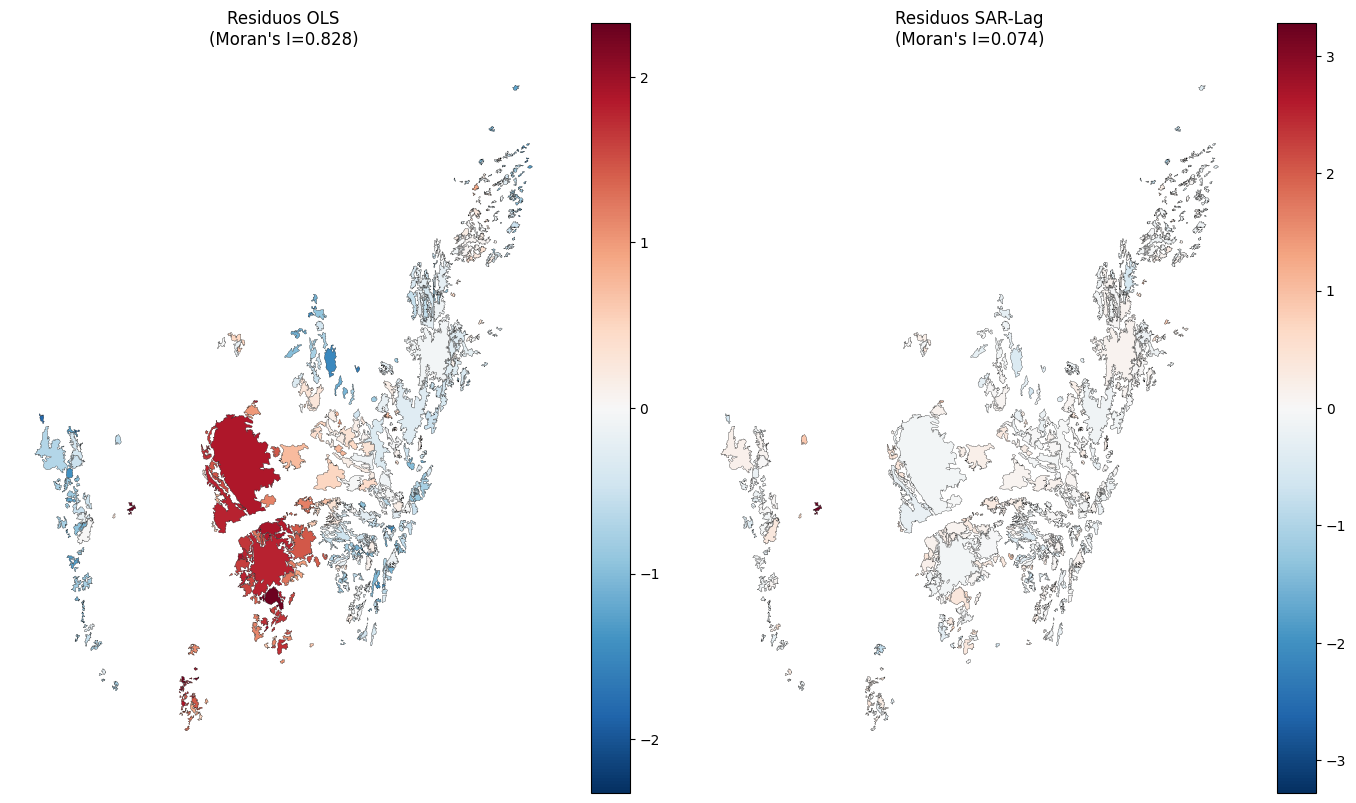

In [16]:
# Guarda los residuos como columnas del GeoDataFrame para mapearlos.
gdf["residuo_ols"] = modelo_ols.u.flatten()
gdf["residuo_sarlag"] = residuos_sarlag

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))
# Mapa de residuos OLS. cmap="RdBu_r" divergente; vmin/vmax simétricos (±max|residuo|) centran el 0 en blanco.
gdf.plot(column="residuo_ols", cmap="RdBu_r", legend=True, edgecolor="black", linewidth=0.2, ax=ax1,
         vmin=-max(abs(gdf["residuo_ols"])), vmax=max(abs(gdf["residuo_ols"])))
ax1.set_title(f"Residuos OLS\n(Moran's I={modelo_ols.moran_res[0]:.3f})")
ax1.set_axis_off()

# Mapa de residuos SAR-Lag (deberían verse "más al azar" = Moran's I bajo).
gdf.plot(column="residuo_sarlag", cmap="RdBu_r", legend=True, edgecolor="black", linewidth=0.2, ax=ax2,
         vmin=-max(abs(gdf["residuo_sarlag"])), vmax=max(abs(gdf["residuo_sarlag"])))
ax2.set_title(f"Residuos SAR-Lag\n(Moran's I={mi_sarlag.I:.3f})")
ax2.set_axis_off()

plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, "01_mapa_residuos_ols_vs_sarlag.png"), dpi=150)
plt.show()

### [11b] Versión cartográfica del mapa de residuos (plantilla con hillshade/norte/escala)

Misma figura de la sección [11], redibujada con la plantilla cartográfica estándar del
proyecto (`plantilla_mapas.py`) en cada uno de los 2 paneles. Esta celda solo llama a la
capa ya calculada (`gdf`) — no repite ningún cálculo del análisis.

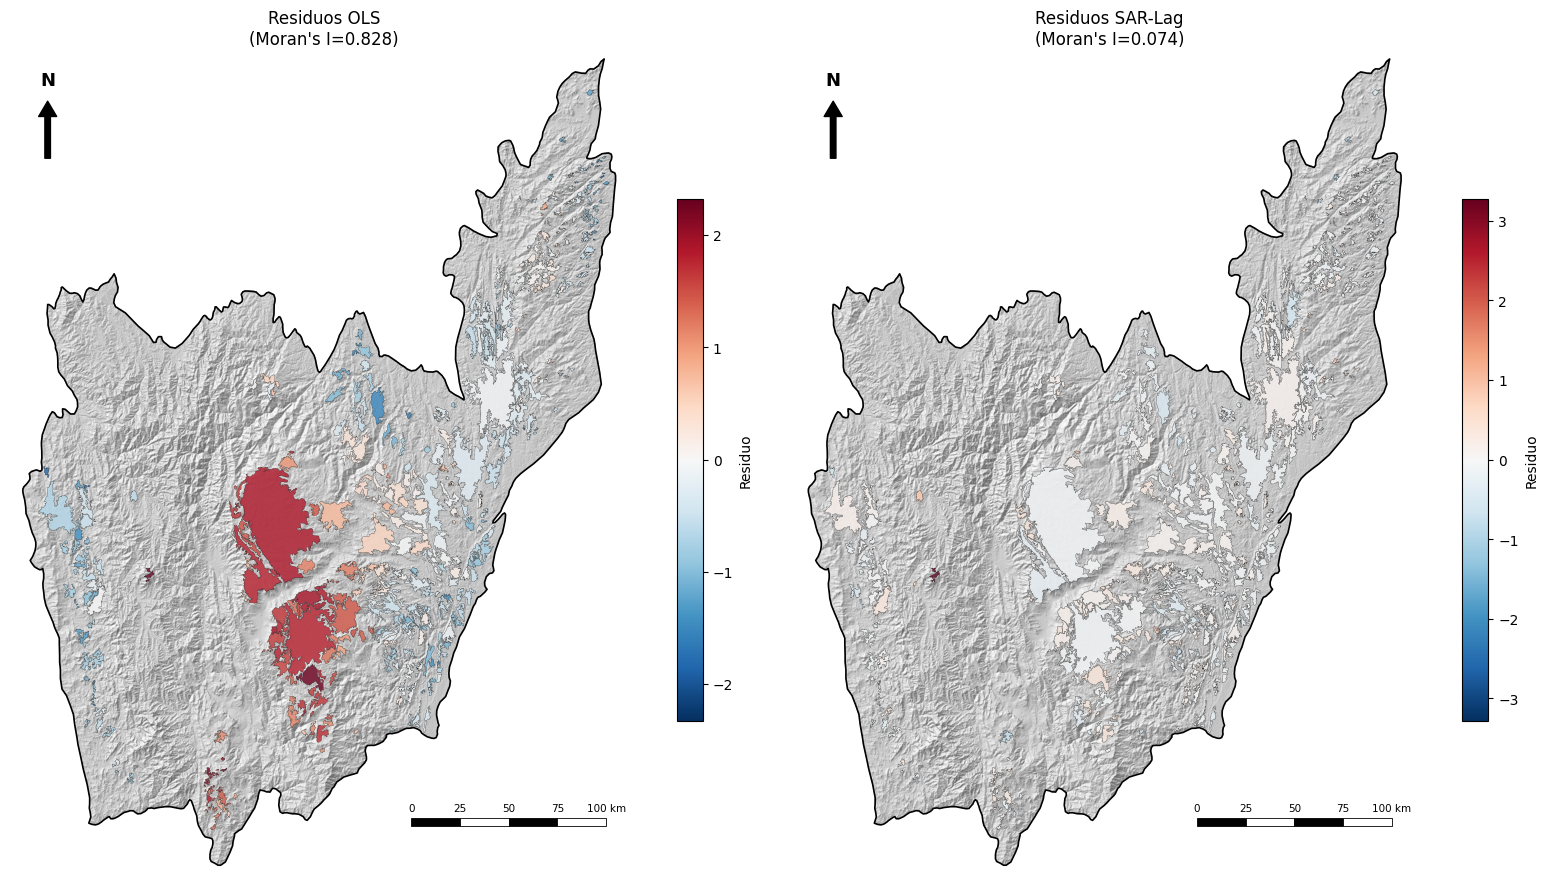

In [17]:
# Versión cartográfica (plantilla) del mapa comparativo de residuos.
from plantilla_mapas import aplicar_plantilla_mapa, CARPETA_IMAGENES

CARPETA_IMAGENES_NB = os.path.join(CARPETA_IMAGENES, "10_SAR_altiplanos_v2")
os.makedirs(CARPETA_IMAGENES_NB, exist_ok=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 9))

# Nota: "residuo_ols"/"residuo_sarlag" son columnas CONTINUAS -> gdf.plot(legend=True) crea un
# colorbar, no una leyenda discreta, asi que aqui NO se usa posicionar_leyenda (esa funcion
# arma un dict para matplotlib Legend, incompatible con los kwargs de un colorbar).
aplicar_plantilla_mapa(ax1, extent_de=gdf)   # fondo hillshade+norte+escala, extent ajustado a los datos
gdf.plot(column="residuo_ols", cmap="RdBu_r", legend=True, edgecolor="black", linewidth=0.2, ax=ax1,
         alpha=0.8, zorder=5, vmin=-max(abs(gdf["residuo_ols"])), vmax=max(abs(gdf["residuo_ols"])),
         legend_kwds={"shrink": 0.6, "label": "Residuo"})   # legend_kwds para el colorbar (tamaño y etiqueta)
ax1.set_title(f"Residuos OLS\n(Moran's I={modelo_ols.moran_res[0]:.3f})")
ax1.set_axis_off()

aplicar_plantilla_mapa(ax2, extent_de=gdf)
gdf.plot(column="residuo_sarlag", cmap="RdBu_r", legend=True, edgecolor="black", linewidth=0.2, ax=ax2,
         alpha=0.8, zorder=5, vmin=-max(abs(gdf["residuo_sarlag"])), vmax=max(abs(gdf["residuo_sarlag"])),
         legend_kwds={"shrink": 0.6, "label": "Residuo"})
ax2.set_title(f"Residuos SAR-Lag\n(Moran's I={mi_sarlag.I:.3f})")
ax2.set_axis_off()

plt.tight_layout()
plt.savefig(os.path.join(CARPETA_IMAGENES_NB, "01_mapa_residuos_ols_vs_sarlag.png"), dpi=150)
plt.show()

## [12] Exportar resultados


In [18]:
ruta_salida = os.path.join(CARPETA_RESULTADOS, "altiplanos_sar_v2.gpkg")
gdf.to_file(ruta_salida, driver="GPKG")   # guarda los polígonos + columnas de residuos como GeoPackage
print(f"Resultado guardado en: {ruta_salida}")

Resultado guardado en: C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\altiplanos_sar_v2.gpkg


## Conclusiones

- La Altitud media de los 491 altiplanos muestra dependencia espacial fuerte que **NO** se
  explica por Pendiente y Relieve: el OLS deja residuos altamente autocorrelacionados
  (Moran's I y ambas pruebas LM muy significativas), justificando un modelo espacial
  explícito.
- SEM y SAR-Lag coinciden en encontrar un parámetro de dependencia espacial (λ y ρ) alto y
  muy significativo — evidencia robusta de que la ubicación importa más allá de la
  morfometría local del propio altiplano.
- El SAR-Lag reduce el Moran's I de sus residuos de forma mucho más marcada que el SEM
  (por construcción, ver sección [10]), lo que lo hace la opción más informativa si el
  objetivo es un modelo con residuos limpios de estructura espacial.
- **Relación con el resto del proyecto:** este hallazgo es consistente con
  `04_autocorrelacion_espacial_v2.ipynb` (Altitud_X ya tenía el Moran's I más alto de las
  tres variables morfométricas) y con `05_modelo_jerarquico_cordilleras_v2.ipynb` (la
  variación de la Altitud/probabilidad de Altiplano entre zonas geográficas es sustancial) —
  ambos apuntan en la misma dirección: existe estructura espacial regional relevante que los
  modelos puramente no-espaciales de este proyecto no capturan.
